# **Trabajo Final Machine Learning — Dataset Titanic**
**Institución Universitaria Pascual Bravo**

**Nombres:** Juan Sebastian Jimenez Sepulveda, Daniela Estrada Machado, Juan Manuel Gonzalez

**Curso:** Machine Learning


## Fase 1. Business Understanding - Comprensión empresarial

**Dataset elegido:** Titanic

**Definición del problema:**  
En este ejercicio buscamos predecir si un pasajero sobrevivió o no al hundimiento del Titanic, ya que en este problema tenemos que clasificar entre 2 resultados se aborda como un problema de clasificación binaria.

**Justificación:**  
Esto resulta algo relevante ya que cuando entendemos estos factores los cuales determinaron la supervivencia en esta tragedia nos permite identificar si hubo sesgos sociales como el género, clase o edad, además de tener un valor educativo en cuanto al análisis de riesgos y discriminacion sistemática en situaciones de emergencia.

**Criterios de éxito:**  
- **Métrica principal:** Para este caso nosotros priorizaremos el Recall o sensibilidad como métrica clave en el trabajo, ya que se nos hace mas critico el detectar correctamente a las personas sobrevivientes que el minimizar falsos positivos.  
- **Métrica secundaria:** como criterio secundario se usará el F1-score por el desbalance de clases que hay entre sobrevivientes con un 62% y no sobrevivientes con un 38%.



## Fase 2. Data Understanding - Comprensión de datos

###2.1  Carga y Descripción del Dataset

In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Carga del dataset
titanic = sns.load_dataset('titanic')
titanic = pd.DataFrame(titanic)

# 2. Dimensiones del dataset
print(f'Dimensiones: {titanic.ndim}D  |  Filas: {titanic.shape[0]}  |  Columnas: {titanic.shape[1]}')
print('\n--- Tipos de datos ')
print(titanic.dtypes)
print('\n-Primeras 5 filas ')
display(titanic.head())

# 4. Resumen estadístico variables numéricas
print('\n- Resumen estadístico (variables numéricas)')
display(titanic.describe())

# 5. Resumen variables categóricas
print('\n- Resumen estadístico (variables categóricas) ')
display(titanic.describe(include='object'))

Dimensiones: 2D  |  Filas: 891  |  Columnas: 15

--- Tipos de datos 
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

-Primeras 5 filas 


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



- Resumen estadístico (variables numéricas)


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



- Resumen estadístico (variables categóricas) 


,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


### 2.2 Análisis inicial: valores nulos, atípicos y desbalance

In [3]:
# Valores nulos
nulos = titanic.isnull().sum()
pct_nulos = (nulos / len(titanic) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, '% Nulos': pct_nulos})
resumen_nulos = resumen_nulos[resumen_nulos['Nulos'] > 0]
print('Variables con valores nulos:')
display(resumen_nulos)

# Desbalance de clase objetivo
print('\nDistribución de la variable objetivo (survived):')
print(titanic['survived'].value_counts())
print(titanic['survived'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

# Detección de atípicos con método IQR
for col in ['fare', 'age']:
    Q1 = titanic[col].quantile(0.25)
    Q3 = titanic[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = titanic[(titanic[col] < Q1 - 1.5*IQR) | (titanic[col] > Q3 + 1.5*IQR)]
    print(f'Atípicos en "{col}": {len(outliers)} filas ({len(outliers)/len(titanic)*100:.1f}%)')

Variables con valores nulos:


,Nulos,% Nulos
age,177,19.87
embarked,2,0.22
deck,688,77.22
embark_town,2,0.22



Distribución de la variable objetivo (survived):
survived
0    549
1    342
Name: count, dtype: int64
survived
0    61.6%
1    38.4%
Name: proportion, dtype: object
Atípicos en "fare": 116 filas (13.0%)
Atípicos en "age": 11 filas (1.2%)


### 2.3 Visualización: relaciones entre variables y la variable objetivo

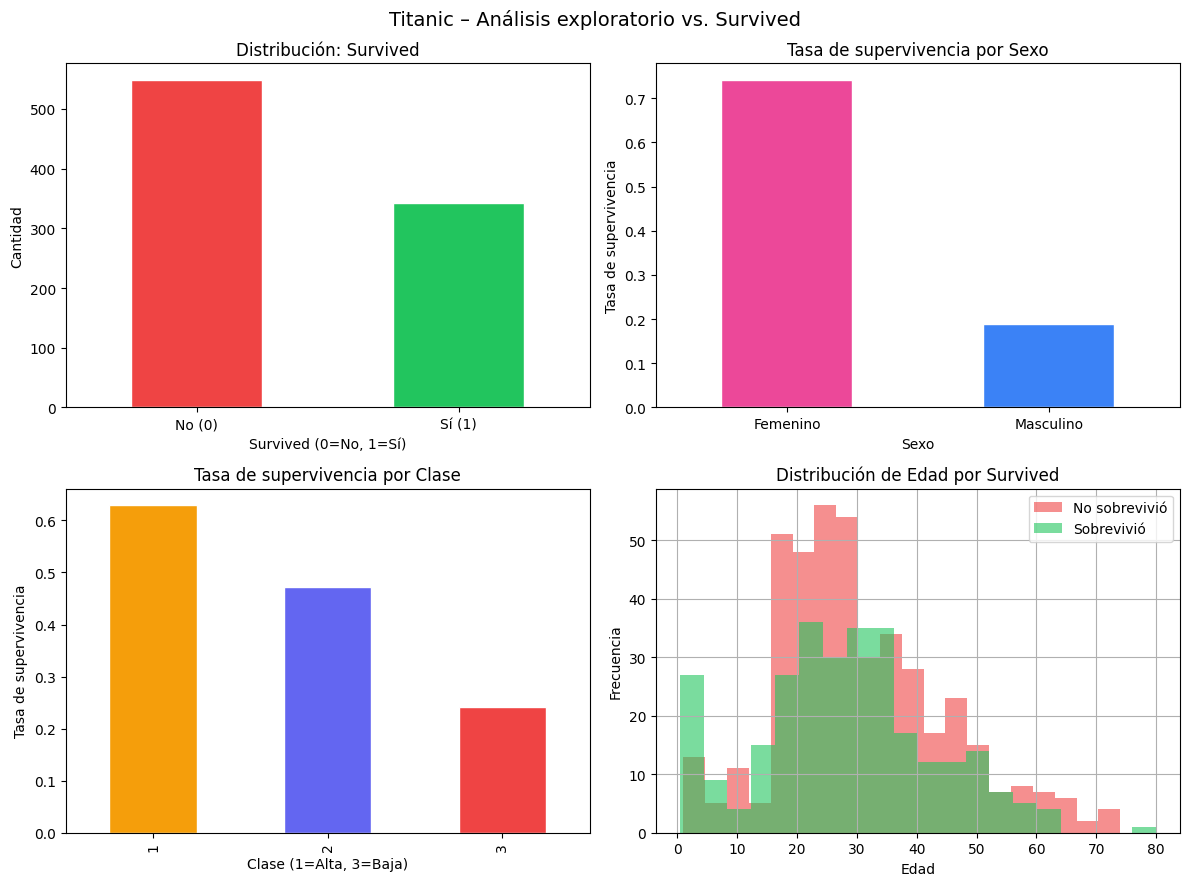

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Titanic – Análisis exploratorio vs. Survived', fontsize=14)

# Gráfico 1: Desbalance de clase objetivo
titanic['survived'].value_counts().plot(kind='bar', ax=axes[0,0],
    color=['#ef4444','#22c55e'], edgecolor='white')
axes[0,0].set_title('Distribución: Survived')
axes[0,0].set_xlabel('Survived (0=No, 1=Sí)')
axes[0,0].set_ylabel('Cantidad')
axes[0,0].set_xticklabels(['No (0)', 'Sí (1)'], rotation=0)

# Gráfico 2: Supervivencia por sexo
titanic.groupby('sex')['survived'].mean().plot(kind='bar', ax=axes[0,1],
    color=['#ec4899', '#3b82f6'], edgecolor='white')
axes[0,1].set_title('Tasa de supervivencia por Sexo')
axes[0,1].set_xlabel('Sexo')
axes[0,1].set_ylabel('Tasa de supervivencia')
axes[0,1].set_xticklabels(['Femenino','Masculino'], rotation=0)

# Gráfico 3: Supervivencia por clase
titanic.groupby('pclass')['survived'].mean().plot(kind='bar', ax=axes[1,0],
    color=['#f59e0b','#6366f1','#ef4444'], edgecolor='white')
axes[1,0].set_title('Tasa de supervivencia por Clase')
axes[1,0].set_xlabel('Clase (1=Alta, 3=Baja)')
axes[1,0].set_ylabel('Tasa de supervivencia')

# Gráfico 4: Distribución de edad por survived
titanic[titanic['survived']==0]['age'].dropna().hist(ax=axes[1,1],
    alpha=0.6, bins=20, color='#ef4444', label='No sobrevivió')
titanic[titanic['survived']==1]['age'].dropna().hist(ax=axes[1,1],
    alpha=0.6, bins=20, color='#22c55e', label='Sobrevivió')
axes[1,1].set_title('Distribución de Edad por Survived')
axes[1,1].set_xlabel('Edad')
axes[1,1].set_ylabel('Frecuencia')
axes[1,1].legend()


plt.tight_layout()
plt.savefig('titanic_eda.png', dpi=150)
plt.show()

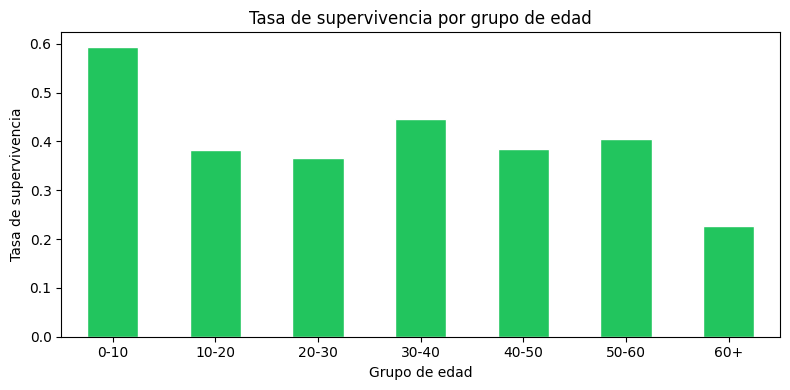

In [5]:
titanic['age_group'] = pd.cut(titanic['age'], bins=[0,10,20,30,40,50,60,80],
                               labels=['0-10','10-20','20-30','30-40','40-50','50-60','60+'])

titanic.groupby('age_group', observed=True)['survived'].mean().plot(kind='bar',
    color='#22c55e', edgecolor='white', figsize=(8,4))
plt.title('Tasa de supervivencia por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Tasa de supervivencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##Fase 3. Data Preparation - Preparación de datos

###3.1 Decisiones de Preprocesamiento e Identificación de Problemas

Variables con valores nulos:


,Nulos,% Nulos
age,177,19.87
embarked,2,0.22
deck,688,77.22
embark_town,2,0.22


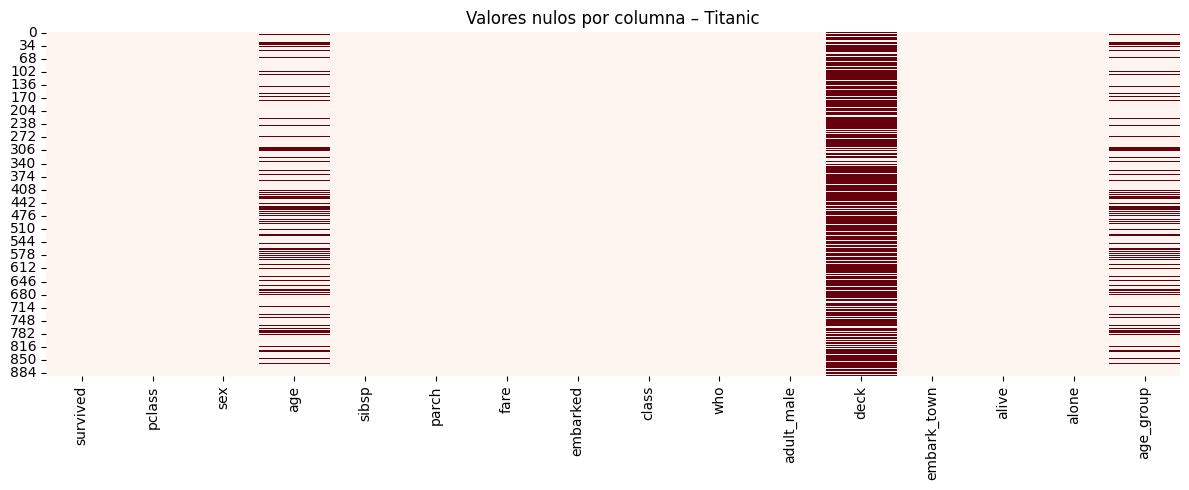

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression

# Identificación de valores nulos

pct_nulos = (nulos / len(titanic) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, '% Nulos': pct_nulos})
resumen_nulos = resumen_nulos[resumen_nulos['Nulos'] > 0]
print('Variables con valores nulos:')
display(resumen_nulos)

# Visualización de valores nulos
plt.figure(figsize=(12, 5))
sns.heatmap(titanic.isnull(), cbar=False, cmap='Reds')
plt.title("Valores nulos por columna – Titanic")
plt.tight_layout()
plt.show()

In [7]:
# Eliminación de columnas poco útiles o redundantes
cols_a_eliminar = ['class', 'who', 'alive', 'adult_male', 'alone', 'deck', 'embark_town']
titanic_clean = titanic.drop(columns=cols_a_eliminar)
# Comparación del dataset original y limpio
print(f'Shape original:  {titanic.shape}')
print(f'Shape tras limpieza: {titanic_clean.shape}')
print(f'\nColumnas conservadas: {list(titanic_clean.columns)}')

Shape original:  (891, 16)
Shape tras limpieza: (891, 9)

Columnas conservadas: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'age_group']


Variables con mas de un 50% de variables nulas son eliminadas, como en este caso deck que tenia un 77% de variables nulas



Del mismo modo variables redundantes o derivadas de otras tambien las quitamos del analisis, esto ya que contienen informacion que viene en otras variables como pueden ser alive la cual es derivada de survived en texto, who y adult_male las cuales son derivadas del junte de sex y age, y alone la cual se  puede reconstruir de sibsp y parch esto asi ya que la variable indica si la persona viajo con algun familiar directo.

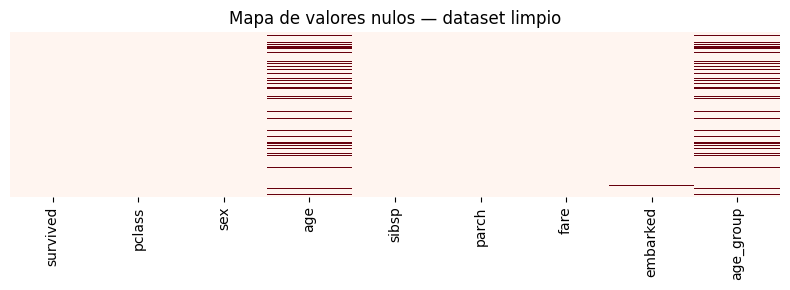

survived       0
pclass         0
sex            0
age          177
sibsp          0
parch          0
fare           0
embarked       2
age_group    177
dtype: int64


In [8]:
# Visualización de mapa de calor de nulos y Verificación posterior de valores nulos
plt.figure(figsize=(8, 3))
sns.heatmap(titanic_clean.isnull(), cbar=False, cmap='Reds', yticklabels=False)
plt.title('Mapa de valores nulos — dataset limpio')
plt.tight_layout()
plt.show()

print(titanic_clean.isnull().sum())

### 3.2 Imputación de Valores Nulos
Imputamos sobre age usando Media, Mediana y regresion lineal; y por ultimo comparamos.

En este caso imputaremos la variable age que fue la variable que nos quedo ahora con mas datos nulos, para eso haremos uso de la media y la mediana para rellenar, y ademas de esto tambien usaremos la regresion lineal en la cual haremos uso de las variables fare y pclass como predictores para estimar las edades faltantes.

Media de age: 29.70 años
Mediana de age: 28.00 años

Imputación por regresión:
  coef fare=-0.043, coef pclass=-7.903
  intercepto=48.868
  Nulos restantes en age: 0


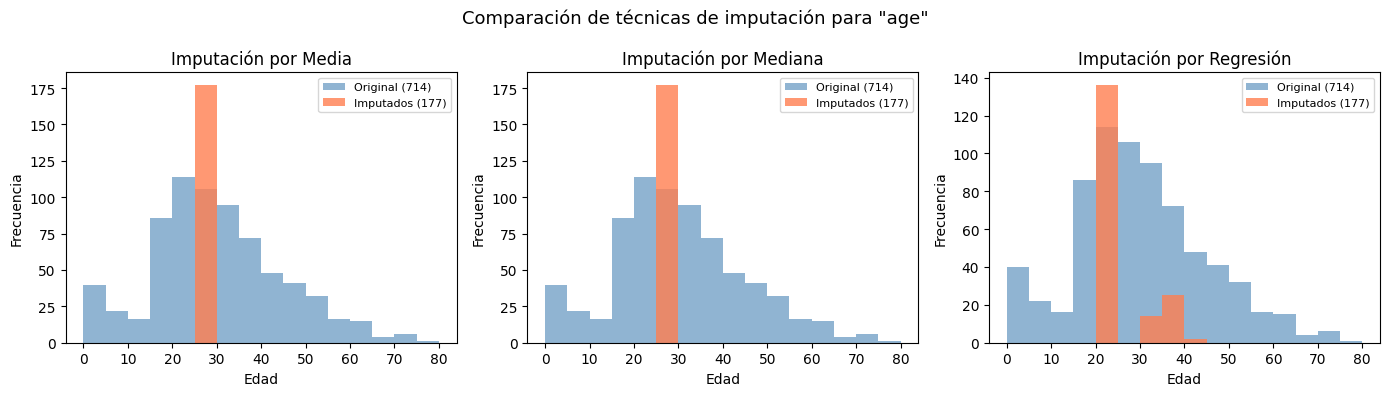

In [9]:
# Técnica 1: Imputación por Media
df_media = titanic_clean.copy()
df_media['age'] = df_media['age'].fillna(df_media['age'].mean())
print(f'Media de age: {titanic_clean["age"].mean():.2f} años')

# Técnica 2: Imputación por Mediana
df_mediana = titanic_clean.copy()
df_mediana['age'] = df_mediana['age'].fillna(df_mediana['age'].median())
print(f'Mediana de age: {titanic_clean["age"].median():.2f} años')

# Técnica 3: Imputación por Regresión Lineal
df_reg = titanic_clean.copy()

# Imputar 'fare' con mediana para evitar NaN en predictores
df_reg['fare'] = df_reg['fare'].fillna(df_reg['fare'].median())

train_reg = df_reg.dropna(subset=['age'])
missing_age_idx = df_reg['age'].isnull()

model_age = LinearRegression()
model_age.fit(train_reg[['fare', 'pclass']], train_reg['age'])

df_reg.loc[missing_age_idx, 'age'] = model_age.predict(
    df_reg.loc[missing_age_idx, ['fare', 'pclass']]
)

# Resultados de la imputación por regresión
print(f'\nImputación por regresión:')
print(f'  coef fare={model_age.coef_[0]:.3f}, coef pclass={model_age.coef_[1]:.3f}')
print(f'  intercepto={model_age.intercept_:.3f}')
print(f'  Nulos restantes en age: {df_reg["age"].isnull().sum()}')

# Comparación visual de técnicas de imputación
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Comparación de técnicas de imputación para "age"', fontsize=13)

datos_originales = titanic_clean['age'].dropna().values
bins = range(0, 85, 5)

for ax, df_imp, titulo in zip(
    axes,
    [df_media, df_mediana, df_reg],
    ['Imputación por Media', 'Imputación por Mediana', 'Imputación por Regresión']
):
    # Extraer solo los valores donde el original era nulo
    solo_imputados = df_imp['age'][titanic_clean['age'].isnull()].values

    ax.hist(datos_originales, bins=bins, alpha=0.6, color='steelblue', label='Original (714)')
    ax.hist(solo_imputados, bins=bins, alpha=0.8, color='coral', label='Imputados (177)')
    ax.set_title(titulo)
    ax.set_xlabel('Edad')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [10]:
# Aplicación final de imputaciones
titanic_prep = titanic_clean.copy()

titanic_prep['age'] = titanic_prep['age'].fillna(titanic_prep['age'].median())
titanic_prep['embarked'] = titanic_prep['embarked'].fillna(titanic_prep['embarked'].mode()[0])

print('✅ Nulos restantes tras preprocesamiento Parte I:')
display(titanic_prep.isnull().sum())
print(f'\nShape final: {titanic_prep.shape}')
display(titanic_prep.head())


✅ Nulos restantes tras preprocesamiento Parte I:


,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
age_group,177



Shape final: (891, 9)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,age_group
0,0,3,male,22.0,1,0,7.2500,S,20-30
1,1,1,female,38.0,1,0,71.2833,C,30-40
2,1,3,female,26.0,0,0,7.9250,S,20-30
3,1,1,female,35.0,1,0,53.1000,S,30-40
4,0,3,male,35.0,0,0,8.0500,S,30-40


En este caso se escogio como metodo de imputacion a la mediana ya que tiene una buena robustez ante valores atipicos, ademas de ser una solucion simple, y aunque la regresion disperso mejor los valoresprodujo coeficientes poco realistas como se puede ver en pclass = -7.9, asi que la mediana en este caso seria la que elegiriamos.

###3.3 LIMPIEZA DE DATOS CATEGÓRICOS

In [11]:
# Eliminación de variables categóricas redundantes

cols_a_eliminar = [
    'class',
    'who',
    'alive',
    'adult_male',
    'alone',
    'deck',
    'embark_town'
]

# Corrección de valores faltantes
# en variable categórica

titanic_prep['embarked'] = titanic_prep[
    'embarked'
].fillna(
    titanic_prep['embarked'].mode()[0]
)
# Tabla de columnas eliminadas

tabla_eliminadas = pd.DataFrame({
    'Columna eliminada': cols_a_eliminar
})

display(tabla_eliminadas)
# Variables conservadas después de la limpieza

columnas_finales = pd.DataFrame({
    'Variables conservadas': titanic_clean.columns
})

display(columnas_finales)

,Columna eliminada
0,class
1,who
2,alive
3,adult_male
4,alone
5,deck
6,embark_town


,Variables conservadas
0,survived
1,pclass
2,sex
3,age
4,sibsp
5,parch
6,fare
7,embarked
8,age_group


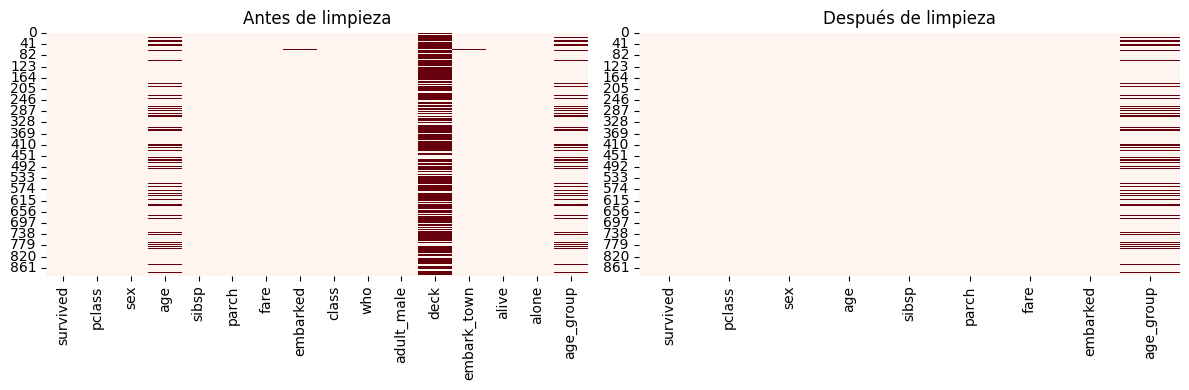

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.heatmap(
    titanic.isnull(),
    cbar=False,
    cmap='Reds',
    ax=axes[0]
)

axes[0].set_title('Antes de limpieza')

sns.heatmap(
    titanic_prep.isnull(),
    cbar=False,
    cmap='Reds',
    ax=axes[1]
)

axes[1].set_title('Después de limpieza')

plt.tight_layout()
plt.show()

##Data Preparation — Parte II

### 3.4 Codificación de variables categóricas (One-Hot Encoding)

Para este caso usamos Sex y embarked para el one one hot encoding ya que estas fueron las unicas variables categoricas que nos quedaron de la limpieza, convirtiendo cada categoria en una columna binaria

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# One-Hot Encoding sobre sex y embarked
titanic_model = pd.get_dummies(titanic_prep, columns=['sex', 'embarked'], drop_first=False)

# Eliminar age_group si quedó del análisis exploratorio
if 'age_group' in titanic_model.columns:
    titanic_model = titanic_model.drop(columns=['age_group'])

print('Columnas tras One-Hot Encoding:')
print(list(titanic_model.columns))
display(titanic_model.head())

Columnas tras One-Hot Encoding:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']


,survived,pclass,age,sibsp,parch,fare,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,False,True,False,False,True
1,1,1,38.0,1,0,71.2833,True,False,True,False,False
2,1,3,26.0,0,0,7.9250,True,False,False,False,True
3,1,1,35.0,1,0,53.1000,True,False,False,False,True
4,0,3,35.0,0,0,8.0500,False,True,False,False,True


Aqui podemos ver como separo las variables categoricas en diferentes grupos separando a sex en sex_male y sex_female; y haciendo lo mismo con embarked separandolo en embarked_C(Puerto de Cherbourg), embarked_Q(Puerto de Queenstown) y embarked_S(Puerto de Southampton).

### 3.5 Definición de features y variable objetivo

In [14]:
# Features (X) y variable objetivo (y)
X = titanic_model.drop(columns=['survived'])
y = titanic_model['survived']

# Columnas numéricas que serán estandarizadas para Naive Bayes
cols_numericas = ['age', 'fare', 'sibsp', 'parch', 'pclass']

print(f'Features del modelo: {list(X.columns)}')
print(f'Variable objetivo: survived (0=No, 1=Sí)')
print(f'Total registros: {len(X)}')

Features del modelo: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']
Variable objetivo: survived (0=No, 1=Sí)
Total registros: 891


### 3.6 División del dataset en entrenamiento y prueba

In [15]:
# División 80% entrenamiento / 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Entrenamiento: {len(X_train)} registros (80%)')
print(f'Prueba:        {len(X_test)} registros  (20%)')
print(f'\nDistribución survived en entrenamiento:')
print(y_train.value_counts())
print(f'\nDistribución survived en prueba:')
print(y_test.value_counts())

Entrenamiento: 712 registros (80%)
Prueba:        179 registros  (20%)

Distribución survived en entrenamiento:
survived
0    444
1    268
Name: count, dtype: int64

Distribución survived en prueba:
survived
0    105
1     74
Name: count, dtype: int64


### 3.7 Estandarización para Naive Bayes


In [16]:
# La estandarización se aplica SOLO para Naive Bayes

scaler = StandardScaler()

X_train_nb = X_train.copy()
X_test_nb  = X_test.copy()

X_train_nb[cols_numericas] = scaler.fit_transform(X_train[cols_numericas])
X_test_nb[cols_numericas]  = scaler.transform(X_test[cols_numericas])

print('Estadísticos tras estandarización (datos de entrenamiento):')
display(X_train_nb[cols_numericas].describe().round(3))

Estadísticos tras estandarización (datos de entrenamiento):


,age,fare,sibsp,parch,pclass
count,712.000,712.000,712.000,712.000,712.000
mean,0.000,0.000,0.000,0.000,0.000
std,1.001,1.001,1.001,1.001,1.001
min,-2.214,-0.627,-0.471,-0.479,-1.614
25%,-0.554,-0.475,-0.471,-0.479,-0.401
50%,-0.093,-0.349,-0.471,-0.479,0.813
75%,0.446,-0.040,0.380,-0.479,0.813
max,3.908,9.238,6.334,7.105,0.813


Aplicamos estandarizacion esto ya que el Naive Bayes lo requiere ya que este asume que los features siguen una distribucion gaussiana, y nosotros tenemos variables con escalas muy diferentes como fare que tiene valores que llegan a 500 y pclass que solo va de 1 a 3, entonces con esta estandarizacion logramos que todas las variables queden con media siendo 0 y desviacion estandar siendo 1, como podemos ver en la tabla.

## Fase 4. Modeling — Modelado

Se entrenan y comparan dos modelos de clasificación supervisada :
- **Modelo 1:** Naive Bayes Gaussiano — clasificador probabilístico.
- **Modelo 2:** Árbol de Decisión — clasificador basado en reglas.

### 4.1 Modelo 1 — Naive Bayes Gaussiano

In [17]:
from sklearn.naive_bayes import GaussianNB

# Crear y entrenar el modelo (con datos estandarizados)
modelo_nb = GaussianNB()
modelo_nb.fit(X_train_nb, y_train)

# Predicciones
y_pred_nb = modelo_nb.predict(X_test_nb)

# Probabilidades predichas
y_prob_nb = modelo_nb.predict_proba(X_test_nb)

print('Naive Bayes Gaussiano entrenado correctamente.')
print(f'\nClases del modelo: {modelo_nb.classes_}')
print(f'\nPrimeras 5 predicciones vs real:')
comparacion = pd.DataFrame({
    'Real':       y_test.values[:5],
    'Predicción': y_pred_nb[:5],
    'Prob clase 0': y_prob_nb[:5, 0].round(3),
    'Prob clase 1': y_prob_nb[:5, 1].round(3)
})
display(comparacion)

Naive Bayes Gaussiano entrenado correctamente.

Clases del modelo: [0 1]

Primeras 5 predicciones vs real:


,Real,Predicción,Prob clase 0,Prob clase 1
0,1,0,0.844,0.156
1,0,0,0.982,0.018
2,0,0,0.990,0.010
3,1,1,0.014,0.986
4,1,1,0.003,0.997


Lo que hace aqui el modelo Naive Bayes es calcular la probabilidad de que un pasajero pertenezca a cada clase siendo, asumiendo que hay independencia entre variables, siendo clase 0 que no sobrevivio y clase 1 que sobrevivio.

### 4.2 Modelo 2 — Árbol de Decisión

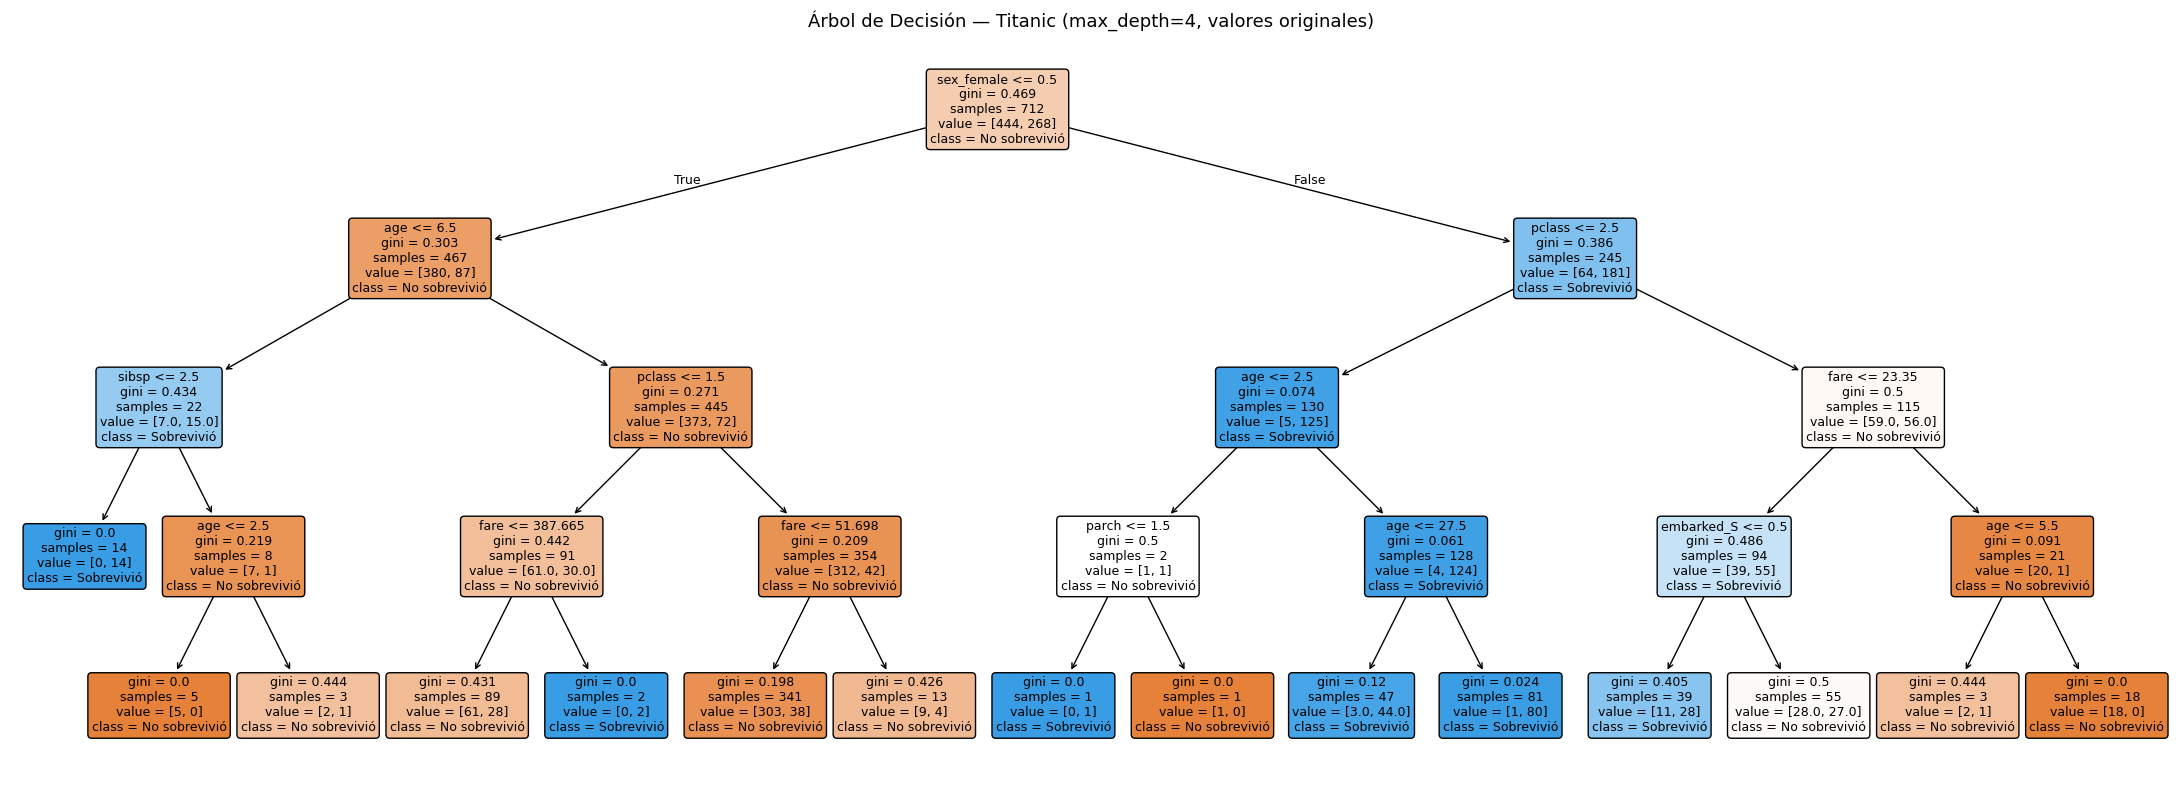

Árbol de Decisión entrenado correctamente.


In [28]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

modelo_dt = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo_dt.fit(X_train, y_train)

# Predicciones
y_pred_dt = modelo_dt.predict(X_test)

# Visualización del árbol con valores originales
plt.figure(figsize=(22, 8))
plot_tree(
    modelo_dt,
    feature_names=list(X.columns),
    class_names=['No sobrevivió', 'Sobrevivió'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Árbol de Decisión — Titanic (max_depth=4, valores originales)', fontsize=13)
plt.tight_layout()
plt.show()

print('Árbol de Decisión entrenado correctamente.')

## Fase 5. Evaluation

Lo que haremos aqui sera evaluar ambos modelos usando las metricas que definimos en el Business Understanding:

- **Recall** (métrica principal): detectar correctamente a los sobrevivientes.
- **F1-Score** (métrica secundaria): balance ante el desbalance de clases.
- Adicionalmente: Accuracy, Precision y Matriz de Confusión.

### 5.1 Métricas de rendimiento por modelo

In [24]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

def evaluar_modelo(nombre, y_test, y_pred):
    print(f'{"="*48}')
    print(f'  {nombre}')
    print(f'{"="*48}')
    print(f'  Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
    print(f'  Precision: {precision_score(y_test, y_pred):.4f}')
    print(f'  Recall:    {recall_score(y_test, y_pred):.4f}  ← métrica principal')
    print(f'  F1-Score:  {f1_score(y_test, y_pred):.4f}  ← métrica secundaria')
    print()
    print(classification_report(y_test, y_pred,
          target_names=['No sobrevivió', 'Sobrevivió']))

evaluar_modelo('Naive Bayes Gaussiano', y_test, y_pred_nb)
evaluar_modelo('Árbol de Decisión',     y_test, y_pred_dt)

  Naive Bayes Gaussiano
  Accuracy:  0.7765
  Precision: 0.7073
  Recall:    0.7838  ← métrica principal
  F1-Score:  0.7436  ← métrica secundaria

               precision    recall  f1-score   support

No sobrevivió       0.84      0.77      0.80       105
   Sobrevivió       0.71      0.78      0.74        74

     accuracy                           0.78       179
    macro avg       0.77      0.78      0.77       179
 weighted avg       0.78      0.78      0.78       179

  Árbol de Decisión
  Accuracy:  0.7765
  Precision: 0.7179
  Recall:    0.7568  ← métrica principal
  F1-Score:  0.7368  ← métrica secundaria

               precision    recall  f1-score   support

No sobrevivió       0.82      0.79      0.81       105
   Sobrevivió       0.72      0.76      0.74        74

     accuracy                           0.78       179
    macro avg       0.77      0.77      0.77       179
 weighted avg       0.78      0.78      0.78       179



### 5.2 Matrices de confusión

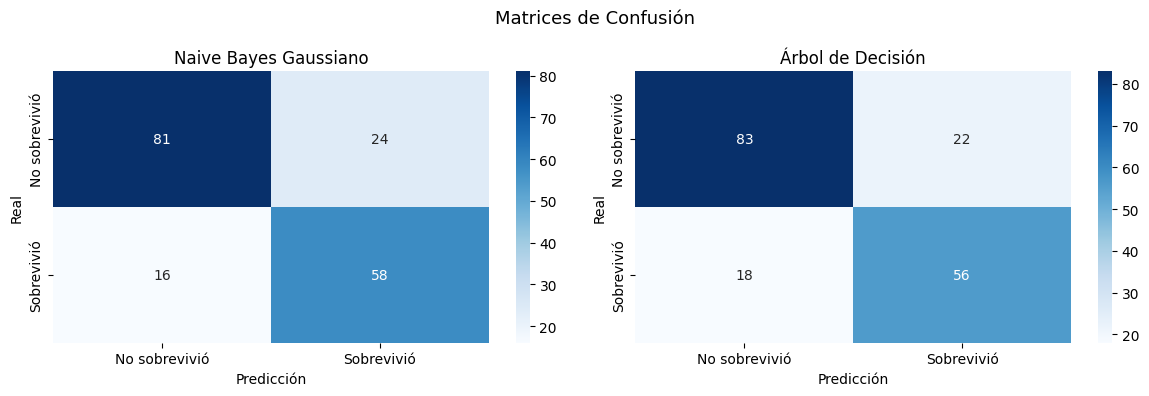

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Matrices de Confusión', fontsize=13)

for ax, y_pred, titulo in zip(
    axes,
    [y_pred_nb, y_pred_dt],
    ['Naive Bayes Gaussiano', 'Árbol de Decisión']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No sobrevivió', 'Sobrevivió'],
                yticklabels=['No sobrevivió', 'Sobrevivió'])
    ax.set_title(titulo)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

En estas matrices podemos ver:

- los **Verdaderos positivos:** los cuales estan abajo a la derecha que son los sobrevivientes que el modelo identifico bien como sobrevivientes, este es el mas importante ya que este es el que nos interesa para el Recall, siendo en naive bayes 58 y en el arbol 56.

- Los **Verdaderos Negativos:** Estos se encuentran arriba a la izquierda, estos corresponden a no sobrevivientes que el modelo identifico de manera correcta, siendo en Naive Bayes de 81 y en el Arbol de 83.

- Los **Falsos Negativos:** Estos se encuentra en el cuadrante de abajo a la izquierda, estos se refieren a no sobrevivientes los cuales el modelo de manera incorrecta clasifico como sobrevivientes, segun nuestro criterio esto resulta algo critico ya que seria poner como muerto alguien que enrealidad si sobrevivio siendo en Naive Bayes de 16 y en el arbol de decisiones siendo de 18.

- Los **Falsos Positivos:** Estos se encuentran arriba a la derecha, estos se refieren a los tripulantes no sobrevivientes que el modelo predijo de forma erronea como sobreviviente.

### 5.3 Comparación visual de métricas

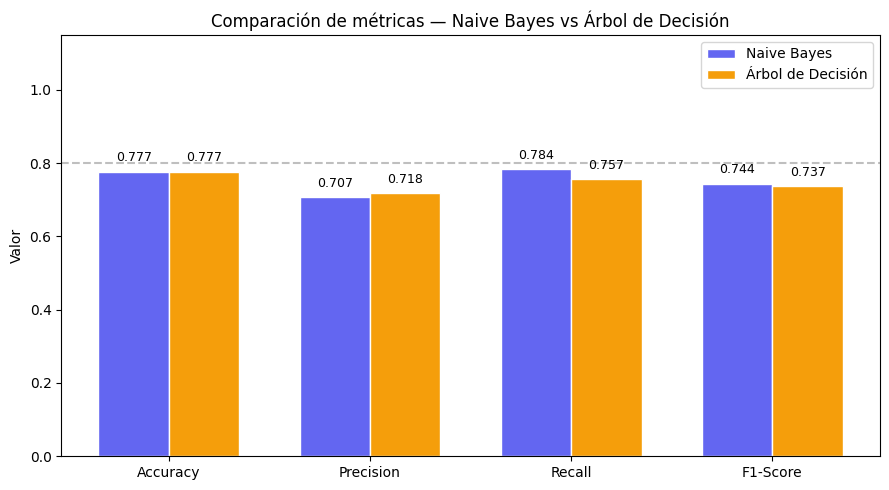

In [26]:
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

valores_nb = [
    accuracy_score(y_test, y_pred_nb),
    precision_score(y_test, y_pred_nb),
    recall_score(y_test, y_pred_nb),
    f1_score(y_test, y_pred_nb)
]
valores_dt = [
    accuracy_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_dt)
]

x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, valores_nb, width, label='Naive Bayes',
               color='#6366f1', edgecolor='white')
bars2 = ax.bar(x + width/2, valores_dt, width, label='Árbol de Decisión',
               color='#f59e0b', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Valor')
ax.set_title('Comparación de métricas — Naive Bayes vs Árbol de Decisión')
ax.legend()
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 5.4 Elección del mejor modelo

In [27]:
resumen = pd.DataFrame({
    'Métrica': metricas,
    'Naive Bayes':       [f'{v:.4f}' for v in valores_nb],
    'Árbol de Decisión': [f'{v:.4f}' for v in valores_dt]
})
display(resumen)

recall_nb = recall_score(y_test, y_pred_nb)
recall_dt = recall_score(y_test, y_pred_dt)
f1_nb     = f1_score(y_test, y_pred_nb)
f1_dt     = f1_score(y_test, y_pred_dt)

print(f'\nRecall   — Naive Bayes: {recall_nb:.4f} | Árbol: {recall_dt:.4f}')
print(f'F1-Score — Naive Bayes: {f1_nb:.4f}  | Árbol: {f1_dt:.4f}')

if recall_nb >= recall_dt:
    mejor = 'Naive Bayes Gaussiano'
else:
    mejor = 'Árbol de Decisión'

print(f'\nModelo seleccionado: {mejor} (mayor Recall)')

,Métrica,Naive Bayes,Árbol de Decisión
0,Accuracy,0.7765,0.7765
1,Precision,0.7073,0.7179
2,Recall,0.7838,0.7568
3,F1-Score,0.7436,0.7368



Recall   — Naive Bayes: 0.7838 | Árbol: 0.7568
F1-Score — Naive Bayes: 0.7436  | Árbol: 0.7368

Modelo seleccionado: Naive Bayes Gaussiano (mayor Recall)


Como habiamos dicho en nuestro data understanding nosotros priorizamos el recall como metrica principal ya que nos parece mas critico el detectar correctamente sobrevivientes que detectar falsos positivos y como metrica secundaria el F1-score el cual actua como un desempate ante el desbalance que hay entre no sobrevivientes y sobrevivientes; teniendo esto en cuenta el modelo elegido sera Naive Bayes al ser el que mas tuvo tanto Recall como F1-Score.

### 5.5 Ética y Sesgos

Segun los diferentes datos que hemos obtenido durante este trabajo hemos podido detectar varios sesgos:

Entre ellos un sesgo de genero con la variable sex, donde podemos ver que el 74% de las mujeres sobrevivieron, una diferencia gigante en comparacion con los hombres que solo sobrevivio el 19%, algo que tiene mucha congruencia con la realidad ya que cuando se estaban subiendo a las barcas para escapar ellos dejaban pasar a mujeres y niños primero.

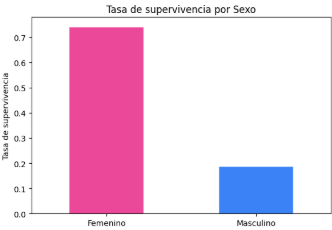



Y hablando de esa politica tambien la podemos ver reflejada en el estudio donde vemos la tasa de supervivencia por grupo de edad donde vemos que el grupo que mas sobrevivio fueron niños entre 0 a 10 años, demostrando que estos fueron de los primeros en dejar salir.

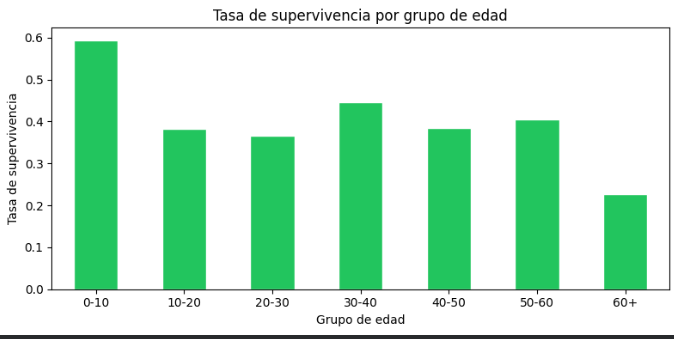

Y por ultimo el sesgo que podemos ver aqui es socioeconomico, esto lo podemos ver al pclass ser una de las variables de corte en el arbol de desiciones, confirmando que esta fue una variable determinante, esto ya que los pasajeros de primera clase tuvieron un acceso prioritario a los botes salvavidas por donde estaban ubicados en el barco.

## Fase 6. Deployment — Despliegue

### 6.1 Reflexión sobre la experiencia CRISP-DM

Durante el proceso que fue el trabajo usando la metodologia Crisp-DM algo que nos dimos cuenta fue que este es algo mas ciclico que lineal, en donde una fase retroalimento las anteriores. Durante el proceso del data understanding pudimos detectar que la variable deck tenia una cantidad muy elevada de nulos lo cual nos forzo a tomar la desicion de eliminarla en data preparation.

Ademas de esto en el analisis exploratorio pudimos ver el desbalance que habia entre los supervivientes y los no supervivientes, algo que nos ayudo a retro alimentar el Business understanding y nos ayudo a decidir a Recall como metrica principal.

### 6.2 Limitaciones del modelo

El modelo Naive Bayes que escogimos al final presenta algunas limitaciones como puede ser:

- El modelo que usamos asume que un supuesto de que todas las variables son independientes entre si, pero en nuestro dataset del titanic esto no se cumple de manera completa ya que sex y pclass estan estan fuertemente correlacionadas con la supervivencia de forma combinadas, esto puede reducir la precision de nuestro modelo.

- El dataset es bastante pequeño con solo 891 registros, algo que hace que el modelo tenga poca capacidad de generalizacion, si el dataset fuera mucho mayor esto permitiria que hubiera patrones mas robusto que capturar asi reduciendo la variabilidad en metricas.

- Hace falta mas informacion relevante que pueda ayudarnos a mejorar signidicativamente las predicciones, variables como ubicacion exacta de los camarotes dentro del barco o el tiempo de reaccion del pasajero al momento de ocurrido el accidente.

### 6.3 Pasos conceptuales para puesta en producción


#### Paso 1 — Serialización del modelo entrenado

En la serializacion lo que hacemos es guardar el modelo ya entrenado en un archivo .pkl, esto nos ayuda ya que enves de ejecutar todo el notebook cada vez que queremos añadir un nuevo pasajero, lo que hacemos es simplemente cargar el archivo y se predice directamente sin tener que entrenarlo de nuevo.

In [32]:
import joblib
import os

# Guardar el modelo Naive Bayes y el scaler en archivos .pkl
# Esto permite reutilizarlos sin necesidad de reentrenar cada vez
joblib.dump(modelo_nb, 'modelo_titanic_nb.pkl')
joblib.dump(scaler,    'scaler_titanic.pkl')

print(' Modelo y scaler serializados correctamente.')
print(f'   Tamaño modelo: {os.path.getsize("modelo_titanic_nb.pkl")} bytes')
print(f'   Tamaño scaler: {os.path.getsize("scaler_titanic.pkl")} bytes')

 Modelo y scaler serializados correctamente.
   Tamaño modelo: 1447 bytes
   Tamaño scaler: 1007 bytes


#### Paso 2 — Cargar el modelo y predecir sobre nuevos datos

Despues procedemos a cargar el modelo e intentar predecir usando datos nuevos, probandolo con diferentes casos:

In [31]:
# Simular carga del modelo desde disco (como lo haría una aplicación en producción)
modelo_cargado = joblib.load('modelo_titanic_nb.pkl')
scaler_cargado = joblib.load('scaler_titanic.pkl')

# Función de predicción reutilizable
def predecir_supervivencia(pclass, age, sibsp, parch, fare,
                            sex, embarked):
    """
    Recibe los datos de un pasajero y retorna la predicción.
    sex: 'female' o 'male'
    embarked: 'S', 'C' o 'Q'
    """
    datos = pd.DataFrame({
        'pclass':       [pclass],
        'age':          [age],
        'sibsp':        [sibsp],
        'parch':        [parch],
        'fare':         [fare],
        'sex_female':   [1 if sex == 'female' else 0],
        'sex_male':     [1 if sex == 'male'   else 0],
        'embarked_C':   [1 if embarked == 'C' else 0],
        'embarked_Q':   [1 if embarked == 'Q' else 0],
        'embarked_S':   [1 if embarked == 'S' else 0],
    })
    datos = datos[X.columns]
    datos[cols_numericas] = scaler_cargado.transform(datos[cols_numericas])

    pred = modelo_cargado.predict(datos)[0]
    prob = modelo_cargado.predict_proba(datos)[0]
    return pred, prob

# ── Casos de prueba ──────────────────────────────────────────
casos = [
    ('Mujer 1a clase',  1, 28, 0, 0, 100.0, 'female', 'C'),
    ('Hombre 3a clase', 3, 25, 0, 0,   7.9, 'male',   'S'),
    ('Niño 2a clase',   2,  6, 1, 2,  30.0, 'male',   'S'),
    ('Mujer 3a clase',  3, 22, 1, 0,   7.9, 'female', 'S'),
]

print('─' * 60)
print(f'{"Caso":<20} {"Predicción":<20} {"Prob. Sobrevivir"}')
print('─' * 60)
for nombre, *params in casos:
    pred, prob = predecir_supervivencia(*params)
    resultado = 'Sobrevivió ✅' if pred == 1 else 'No sobrevivió ❌'
    print(f'{nombre:<20} {resultado:<20} {prob[1]:.2%}')
print('─' * 60)

────────────────────────────────────────────────────────────
Caso                 Predicción           Prob. Sobrevivir
────────────────────────────────────────────────────────────
Mujer 1a clase       Sobrevivió ✅         100.00%
Hombre 3a clase      No sobrevivió ❌      0.89%
Niño 2a clase        No sobrevivió ❌      3.44%
Mujer 3a clase       Sobrevivió ✅         93.23%
────────────────────────────────────────────────────────────


#### Paso 3 — Esquema conceptual de API para producción

Se usaria una API Flask la cual expone el modelo como un servicio web. Asi cualquier aplicacion podra enviarle datos de un pasajero en formato JSON y asi recibir respuesta de la prediccion.

#### Paso 4 - Subir notebook a repositorio github

Este notebook se encontrara subido a un repositorio de github para que todos puedan ingresar y descargarlo, para ser usado

[Link repo trabajo final Titanic](https://github.com/JuanSebastianJimenez669/TrabajoFinal-ML-Titanix)